In [1]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.metrics import r2_score, root_mean_squared_error

In [2]:
df = pd.read_csv("housing.csv")
df["rooms_per_household"] = df["total_rooms"] / df["households"]
print("\nMissing per column:\n", df.isna().sum())


Missing per column:
 longitude                0
latitude                 0
housing_median_age       0
total_rooms              0
total_bedrooms         207
population               0
households               0
median_income            0
median_house_value       0
ocean_proximity          0
rooms_per_household      0
dtype: int64


Missing values i total_bedrooms. Fyller med median

In [3]:
y = df["median_house_value"]
X = df.drop(columns=["median_house_value"])

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

numeric_features = ["longitude", "latitude", "housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income", "rooms_per_household"]
categorical_features = ["ocean_proximity"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (16512, 10)
Test shape: (4128, 10)


In [4]:
print("Dtypes:\n", X_train.dtypes)
print("\nMissing per column:\n", X_train.isna().sum())

Dtypes:
 longitude              float64
latitude               float64
housing_median_age     float64
total_rooms            float64
total_bedrooms         float64
population             float64
households             float64
median_income          float64
ocean_proximity         object
rooms_per_household    float64
dtype: object

Missing per column:
 longitude              0
latitude               0
housing_median_age     0
total_rooms            0
total_bedrooms         0
population             0
households             0
median_income          0
ocean_proximity        0
rooms_per_household    0
dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

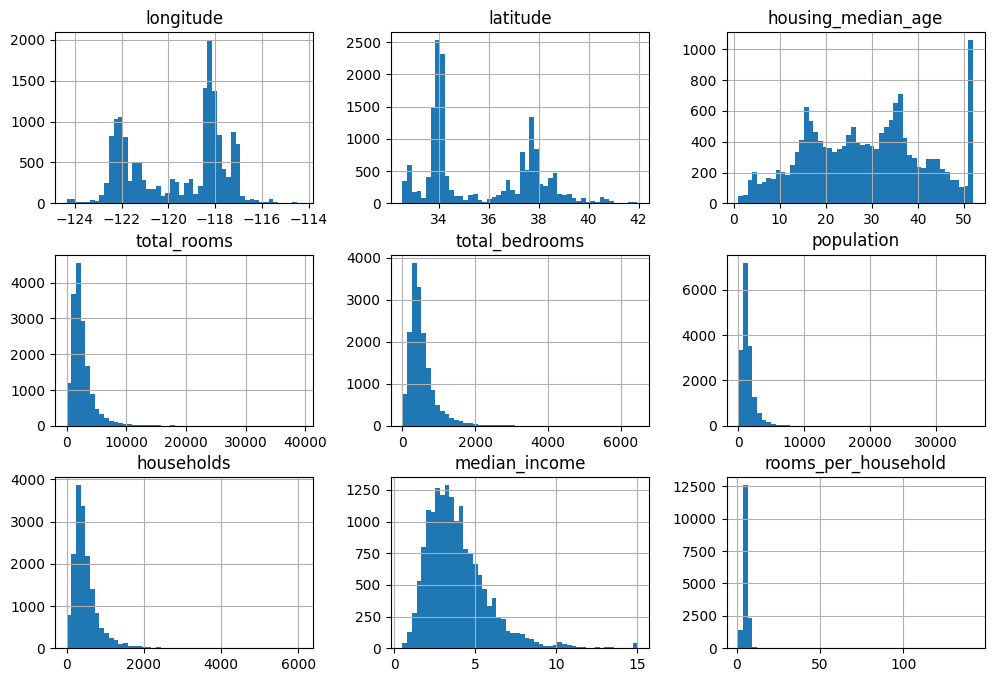

In [5]:
X_train.hist(bins=50, figsize=(12,8))
plt.show

Rooms_per_household innehåller outliers. Inte rimligt att fastighet har 100 rum. För att begränsa deras påverkan används clipping. 

In [6]:
X_train["rooms_per_household"] = X_train["rooms_per_household"].clip(upper=30)

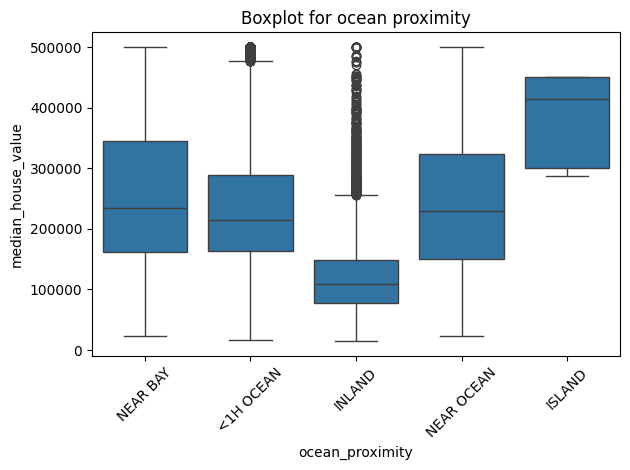

In [22]:
sns.boxplot(x=X["ocean_proximity"], y=y)
plt.xticks(rotation=45)
plt.title("Boxplot for ocean proximity")
plt.tight_layout()
plt.savefig("box_plot_ocean_proximity.png", dpi=150)
plt.show()

Visualiseringen visar att priserna genomsnittligt är högre om fastigheten ligger nära vatten jämfört med inåt landet.

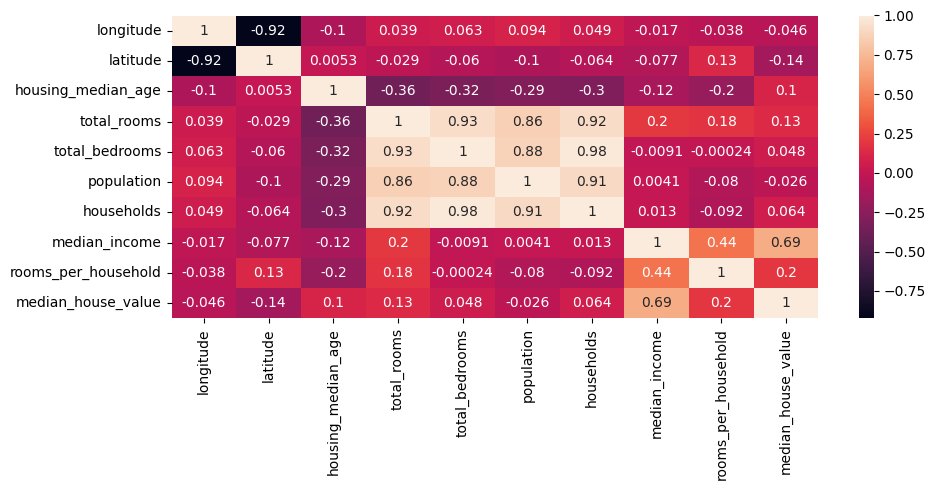

In [24]:
df_for_matrix = X_train.copy()
df_for_matrix["median_house_value"] = y_train

correlation_matrix = df_for_matrix.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(correlation_matrix, annot=True, ax=ax)
plt.tight_layout()

plt.savefig("correlation_matrix.png", dpi=150)
plt.show()

Det ser ut som median_house_value har den starkaste korrelationen med median_income. 

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [10]:
baseline_linear_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

ridge_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge())
])

lasso_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Lasso(max_iter=10000))
])

elastic_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", ElasticNet(max_iter=10000))
])

models = {
    "Linear Regression": baseline_linear_pipe,
    "Ridge": ridge_pipe,
    "Lasso": lasso_pipe,
    "ElasticNet": elastic_pipe
}

In [11]:
results = []

for name, model in models.items():
    rmse_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    r2_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    results.append({
        "model": name,
        "RMSE": -rmse_scores.mean(),
        "R2": r2_scores.mean()
    })

results_df = pd.DataFrame(results)
results_df

,model,RMSE,R2
0,Linear Regression,68592.506457,0.647854
1,Ridge,68591.673671,0.647864
2,Lasso,68592.541618,0.647854
3,ElasticNet,78341.465834,0.540751


In [12]:
ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(
        estimator=ridge_pipe,
        param_grid=ridge_param_grid,
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

ridge_grid.fit(X_train, y_train)


print("Best RMSE:", -ridge_grid.best_score_)
print("Best parameters", ridge_grid.best_params_)

Best RMSE: 68591.67367065803
Best parameters {'model__alpha': 1.0}


In [15]:
best_model = ridge_grid.best_estimator_

y_pred = best_model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

result_best_model_df = pd.DataFrame({
    "Model": ["Ridge - train", "Ridge - test"],
    "RMSE": [round(results_df.iloc[0,1], 0), round(rmse, 0)],
    "R²": [round(results_df.iloc[1,2], 2), round(r2, 2)]
})

result_best_model_df

,Model,RMSE,R²
0,Ridge - train,68593.0,0.65
1,Ridge - test,69885.0,0.63
